# Práctica 1


En primera instancia se definen las librerías utilizadas en esta primera práctica permitiendo cv2 hacer uso de la biblioteca OpenCV que nos permite procesar imágenes y vídeos en tiempo real, numpy para realizar cómputo numérico con funciones matemáticas implementadas en esta biblioteca y pyplot de matplotlib para representar gráficamente.

In [1]:
import cv2
import time
import numpy as np
import matplotlib.pyplot as plt

En esta segunda celda se establecen las dimensiones de la imagen a representar como variables comunes.

In [2]:
ancho = 800
alto = 800

Este código representa el desarrollo del tablero de ajedrez sin hacer uso de la inteligencia generativa, pintando todo el espacio en negro para que actúe como lienzo. Esta decisión permite pintar mediante dos bucles anidados casillas blancas, aplicando una condición adelantando la posición de inicio en las filas impares para generar el efecto visual de cuadradados blancos y negros propios de un tablero de ajedrez.

Dimensiones de la imagen: (800, 800, 1)


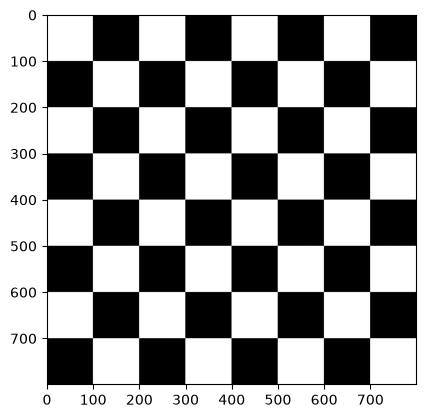

In [4]:
# Código generado sin IA
color_img = np.zeros((alto,ancho,1), dtype = np.uint8)

def metodo_iterativo(color_img):
    alto = color_img.shape[0]
    ancho = color_img.shape[1]

    alto_casilla = alto // 8
    ancho_casilla = ancho // 8

    x1 = 0
    for i in range(0, 8):
        x2 = x1 + alto_casilla
        if i % 2 != 0:
            y1 = ancho_casilla
        else:
            y1 = 0
        for j in range(0, 4):
            y2 = y1 + ancho_casilla
            color_img[x1:x2, y1:y2, 0] = 255
            y1 += ancho_casilla * 2
        x1 += alto_casilla

    return color_img

print("Dimensiones de la imagen:", metodo_iterativo(color_img).shape)
plt.imshow(metodo_iterativo(color_img), cmap='gray')
plt.show()

En el desarrollo de generar el tablero de ajedrez con inteligencia generativa (Gemini), se puede observa la sintexis de código al implementar una función que representa la lógica matemática mediante vectorización.

Dimensiones de la imagen: (800, 800, 1)


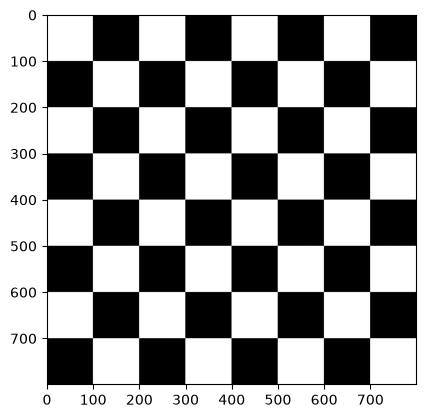

In [5]:
#Códgio generado con IA

paso = alto//8

def metodo_declarativo():
    y, x = np.indices((alto, ancho))
    ajedrez_2d = (((y // paso) + (x // paso)) % 2 == 0).astype(np.uint8) * 128
    return np.expand_dims(ajedrez_2d, axis=-1)


print("Dimensiones de la imagen:", metodo_declarativo().shape)
plt.imshow(metodo_declarativo(), cmap='gray')
plt.show()



Para poder llevar a cabo una comparativa de ambas implementaciones se ha calculado el tiempo de ejecución medio en diez ejecuciones pudiendo observarse que el código iterativo es más eficiente.

In [6]:
num_ejecuciones = 10
tiempos_iterativo = []
tiempos_declarativo = []

for _ in range(num_ejecuciones):
    color_img = np.zeros((alto, ancho, 1), dtype=np.uint8)

    # Medición del método iterativo
    inicio = time.perf_counter()
    resultado_iterativo = metodo_iterativo(color_img)
    fin = time.perf_counter()
    tiempos_iterativo.append(fin - inicio)

    # Medición del método declarativo
    inicio2 = time.perf_counter()
    resultado_declarativo = metodo_declarativo()
    fin2 = time.perf_counter()
    tiempos_declarativo.append(fin2 - inicio2)

# Calculamos la media y la desviación estándar con NumPy
tiempo_medio = np.mean(tiempos_iterativo)
std_iterativo = np.std(tiempos_iterativo)

tiempo2_medio = np.mean(tiempos_declarativo)
std_declarativo = np.std(tiempos_declarativo)

print("El tiempo medio de ejecución del código generado sin IA es de %.5f ± %.5f segundos." %(tiempo_medio, std_iterativo))
print("El tiempo medio de ejecución del código generado utilizando IA es de %.5f ± %.5f segundos." %(tiempo2_medio, std_declarativo))

# Relación de tiempos
if tiempo_medio < tiempo2_medio:
    proporcion = tiempo2_medio / tiempo_medio
    print("Por tanto, el código generado por IA es más lento en términos de ejecución %.2f veces frente a la versión iterativa." % proporcion)
else:
    proporcion = tiempo_medio / tiempo2_medio
    print("Por tanto, el código generado por IA es más rápido en términos de ejecución %.2f veces frente a la versión iterativa." % proporcion)

El tiempo medio de ejecución del código generado sin IA es de 0.00015 ± 0.00015 segundos.
El tiempo medio de ejecución del código generado utilizando IA es de 0.01264 ± 0.00079 segundos.
Por tanto, el código generado por IA es más lento en términos de ejecución 86.54 veces frente a la versión iterativa.


En esta segunda tarea, haciendo uso de funciones propias de OpenCV se han trazado líneas y creado rectángulos de colores para lograr una representación gráfica de estilo Mondrian.

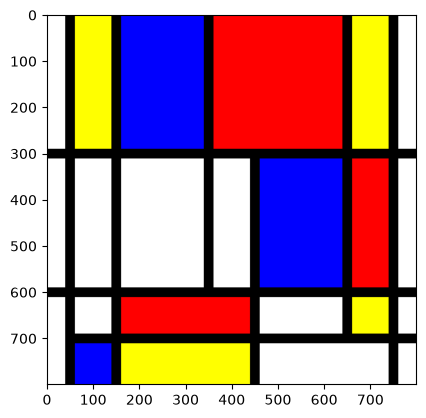

True

In [7]:
#Crea una imagen con tres planos
color_img = np.zeros((alto,ancho,3), dtype = np.uint8)
color_img[:] = 255


#Rectángulos
cv2.rectangle(color_img,(60,0),(140,290),(255,255,0),-1)
cv2.rectangle(color_img,(160,0),(340,290),(0,0,255),-1)
cv2.rectangle(color_img,(360,0),(640,290),(255,0,0),-1)
cv2.rectangle(color_img,(660,0),(740,290),(255,255,0),-1)
cv2.rectangle(color_img,(460,310),(640,590),(0,0,255),-1)
cv2.rectangle(color_img,(660,310),(740,590),(255,0,0),-1)
cv2.rectangle(color_img,(160,610),(440,690),(255,0,0),-1)
cv2.rectangle(color_img,(660,610),(740,690),(255,255,0),-1)
cv2.rectangle(color_img,(60,710),(140,800),(0,0,255),-1)
cv2.rectangle(color_img,(160,710),(440,800),(255,255,0),-1)


#Líneas verticales
cv2.line(color_img,(50,0),(50,alto),(0,0,0),20)
cv2.line(color_img,(150,0),(150,alto),(0,0,0),20)
cv2.line(color_img,(350,0),(350,600),(0,0,0),20)
cv2.line(color_img,(450,300),(450,alto),(0,0,0),20)
cv2.line(color_img,(650,0),(650,700),(0,0,0),20)
cv2.line(color_img,(750,0),(750,alto),(0,0,0),20)

#Líneas horizontales
cv2.line(color_img,(0,300),(ancho,300),(0,0,0),20)
cv2.line(color_img,(0,600),(ancho,600),(0,0,0),20)
cv2.line(color_img,(50,700),(ancho,700),(0,0,0),20)
#Visualiza sin especificar el mapa de color gris
plt.imshow(color_img)
plt.show()

#Convierte la imagen de RGB a BGR para que OpenCV la entienda
color_img_bgr = cv2.cvtColor(color_img, cv2.COLOR_RGB2BGR)

#Salva la imagen resultante a disco
cv2.imwrite('imagen.jpg', color_img_bgr)

**TAREA**:
Pintar círculos en las posiciones del píxel más claro y oscuro de cada fotograma captado por la cámara. ¿Funciona de forma fluida o a saltos? En el segundo caso, ¿podrías acelerarlo?
Si haces uso de herramientas de IA, incluye la conversación.


Para resolver esta tarea se convierte primero cada fotograma a escala de grises con `cv2.cvtColor`, 
de forma que la comparación de intensidad se realice sobre un único canal en lugar de sobre los tres del color. 
En esta primera versión, sin inteligencia generativa, se recorre el fotograma píxel a píxel mediante dos bucles anidados en Python, 
actualizando el valor mínimo y máximo junto con sus coordenadas conforme se avanza.

In [ ]:
# Lento con retardo Sin IA

vid = cv2.VideoCapture(0)


while(True):
    # fotograma a fotograma
    ret, frame = vid.read()

    if ret:
        frame_gris = cv2.cvtColor(frame, cv2.COLOR_BGR2GRAY)
        h, w = frame_gris.shape

        # 0 oscuro, 255 claro
        min_val = 255
        max_val = 0
        pos_min = (0, 0)
        pos_max = (0, 0)

        for y in range(0, h):
            for x in range(0, w):
                valor = frame_gris[y, x]

                if valor < min_val:
                        min_val = valor
                        pos_min = (x, y) # Guardamos coordenada para dibujar

                if valor > max_val:
                    max_val = valor
                    pos_max = (x, y)
        cv2.circle(frame, pos_min, 15, (255, 0, 0), -1) # Azul oscuro
        cv2.circle(frame, pos_max, 15, (0, 0, 255), -1) # Rojo claro

        cv2.imshow('Vid', frame)

    if cv2.waitKey(20) == 27:
        break
# Libera el objeto de captura
vid.release()
# Destruye ventanas
cv2.destroyAllWindows()

El recorrido explícito en Python resulta muy lento por evaluarse más de 300.000 píxeles por fotograma dentro del intérprete, 
provocando un vídeo a saltos y con retardo perceptible. Para acelerarlo se ha solicitado ayuda a la inteligencia generativa (Gemini), 
que propuso sustituir el doble bucle por la función `cv2.minMaxLoc()` de OpenCV, 
la cual devuelve en una sola llamada los valores mínimo y máximo junto con sus posiciones, delegando el recorrido a código nativo vectorizado. 
Con este cambio la visualización pasa a ser fluida, confirmando que el cuello de botella era el bucle en Python y no la operación en sí.

In [ ]:
# Acelerado y fluido con IA

vid = cv2.VideoCapture(0)

while(True):
    ret, frame = vid.read()

    if ret:
        # 1. Pasamos a escala de grises
        frame_gris = cv2.cvtColor(frame, cv2.COLOR_BGR2GRAY)

        # 2. Búsqueda optimizada (Sustituye a todo tu bloque 'for')
        min_val, max_val, pos_min, pos_max = cv2.minMaxLoc(frame_gris)

        # 3. Dibujamos los círculos usando las posiciones devueltas
        cv2.circle(frame, pos_min, 15, (255, 0, 0), -1) # Azul en el más oscuro
        cv2.circle(frame, pos_max, 15, (0, 0, 255), -1) # Rojo en el más claro

        cv2.imshow('Vid', frame)

    if cv2.waitKey(20) == 27:
        break

vid.release()
cv2.destroyAllWindows()

TAREA: Llevar a cabo una propuesta propia de pop art.
Incluye fuentes consultadas.
Si haces uso de herramientas de IA, incluye la conversación.

Como propuesta propia de pop art se ha optado por dividir cada fotograma de la cámara en tres tiras verticales de igual anchura, 
que se recolocan en un orden distinto al original para generar una composición fragmentada. 
Sobre cada tira se aplica además una manipulación distinta de los canales de color: en la primera se permutan los canales entre sí, 
mientras que en las otras dos se invierte uno de los canales mediante el complemento `255 - canal`.

In [ ]:
# Coger tiras verticales cambiarlas de orden y meterle un filtro en cada canal

vid = cv2.VideoCapture(0)
w = int(vid.get(cv2.CAP_PROP_FRAME_WIDTH))
h = int(vid.get(cv2.CAP_PROP_FRAME_HEIGHT))
collage = np.zeros((h,w,3), dtype = np.uint8)

# Para que tordos los cortes sean iguales
tercio = int(w/3)
while(True):
    # fotograma a fotograma
    ret, frame = vid.read()

    if ret:

        collage[:, 0:tercio, 0] = frame[:, tercio*2:tercio*3, 2]
        collage[:, 0:tercio, 1] = frame[:, tercio*2:tercio*3, 1]
        collage[:, 0:tercio, 2] = frame[:, tercio*2:tercio*3, 0]

        collage[:, tercio:tercio*2, 0] = frame[:, tercio:tercio*2, 2]
        collage[:, tercio:tercio*2, 1] = 255 - frame[:, tercio:tercio*2, 0]
        collage[:, tercio:tercio*2, 2] = frame[:, tercio:tercio*2, 1]

        collage[:, tercio*2:tercio*3, 0] = 255 - frame[:, 0:tercio, 2]
        collage[:, tercio*2:tercio*3, 1] = frame[:, 0:tercio, 1]
        collage[:, tercio*2:tercio*3, 2] = frame[:, 0:tercio, 0]


        cv2.imshow('Vid', collage)

    if cv2.waitKey(20) == 27:
        break
# Libera el objeto de captura
vid.release()
# Destruye ventanas
cv2.destroyAllWindows()